### Model Training Pipeline
Feature Engineering → Selection → SMOTE → XGBoost → Threshold Tuning

Setup & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv("../outputs/outliers_handled.csv")
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())
print(f"\nTarget: {df['Target'].value_counts().to_dict()}")

Loaded shape: (149233, 11)
Columns: ['Target', 'RevolvingUtilization', 'Age', 'Times30_59Late', 'DebtRatio', 'MonthlyIncome', 'OpenCreditLines', 'Times90Late', 'RealEstateLines', 'Times60_89Late', 'Dependents']

Target: {0: 139229, 1: 10004}


Feature Engineering

Adding 3 new features that combine weak signals into stronger ones.

In [5]:
# 1. Total late payments — combining 3 separate late payment columns into one
df["TotalLatePayments"] = df["Times30_59Late"] + df["Times60_89Late"] + df["Times90Late"]

# 2. Has severe delinquency 
df["HasSevereDelinquency"] = (df["Times90Late"] > 0).astype(int)

# 3. Income to debt ratio 
df["IncomeDebtRatio"] = df["MonthlyIncome"] / (df["DebtRatio"] + 1)

print("Engineered features added:")
print(f"  TotalLatePayments     : min={df['TotalLatePayments'].min()}, max={df['TotalLatePayments'].max()}")
print(f"  HasSevereDelinquency  : {df['HasSevereDelinquency'].value_counts().to_dict()}")
print(f"  IncomeDebtRatio       : median={df['IncomeDebtRatio'].median():.1f}")

# Capping IncomeDebtRatio at 99th percentile 
cap = df["IncomeDebtRatio"].quantile(0.99)
df["IncomeDebtRatio"] = df["IncomeDebtRatio"].clip(upper=cap)

print(f"\nShape after engineering: {df.shape}")
print(f"All features: {[c for c in df.columns if c != 'Target']}")

Engineered features added:
  TotalLatePayments     : min=0, max=60
  HasSevereDelinquency  : {0: 140961, 1: 8272}
  IncomeDebtRatio       : median=3370.2

Shape after engineering: (149233, 14)
All features: ['RevolvingUtilization', 'Age', 'Times30_59Late', 'DebtRatio', 'MonthlyIncome', 'OpenCreditLines', 'Times90Late', 'RealEstateLines', 'Times60_89Late', 'Dependents', 'TotalLatePayments', 'HasSevereDelinquency', 'IncomeDebtRatio']


### Validation Strategy Justification

We use a **70/15/15 stratified Train/Validation/Test split** combined with **5-Fold Stratified Cross-Validation**:

- **Training set (70%)**: Used to train the model. SMOTE is applied only here.
- **Validation set (15%)**: Used for model development — feature selection, threshold tuning, and comparing approaches. We iterate on this set multiple times.
- **Test set (15%)**: Touched only ONCE at the very end for final unbiased evaluation. This simulates true unseen data.
- **Stratified splitting** ensures all three sets maintain the original 93/7 class ratio.
- **5-Fold CV** is run separately to confirm consistency across different data splits.

In [6]:
feature_cols = [col for col in df.columns if col != "Target"]
X = df[feature_cols]
y = df["Target"]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: split the 30% into 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set  : {X_train.shape[0]:,} rows (70%)")
print(f"Validation set: {X_val.shape[0]:,} rows (15%)")
print(f"Test set      : {X_test.shape[0]:,} rows (15%)")
print(f"Features      : {len(feature_cols)}")

print(f"\nTarget distribution per split:")
for name, ys in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {name:<6}: No Default {(ys==0).sum():>7,} ({(ys==0).mean()*100:.1f}%) | Default {(ys==1).sum():>5,} ({(ys==1).mean()*100:.1f}%)")

Training set  : 104,463 rows (70%)
Validation set: 22,385 rows (15%)
Test set      : 22,385 rows (15%)
Features      : 13

Target distribution per split:
  Train : No Default  97,460 (93.3%) | Default 7,003 (6.7%)
  Val   : No Default  20,884 (93.3%) | Default 1,501 (6.7%)
  Test  : No Default  20,885 (93.3%) | Default 1,500 (6.7%)


Scaling (fit on train only)

In [7]:
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
print("RobustScaler fitted on training set, applied to train/val/test")

RobustScaler fitted on training set, applied to train/val/test


SMOTE(sampling_strategy=0.7)

In [8]:
print("BEFORE SMOTE:")
print(f"  Class 0: {(y_train == 0).sum():,}")
print(f"  Class 1: {(y_train == 1).sum():,}")
print(f"  Ratio  : {(y_train == 0).sum() / (y_train == 1).sum():.1f}:1")

smote = SMOTE(random_state=42, sampling_strategy=0.7)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAFTER SMOTE (ratio=0.7):")
print(f"  Class 0: {(y_train_sm == 0).sum():,}")
print(f"  Class 1: {(y_train_sm == 1).sum():,}")
print(f"  Ratio  : {(y_train_sm == 0).sum() / (y_train_sm == 1).sum():.1f}:1")

BEFORE SMOTE:
  Class 0: 97,460
  Class 1: 7,003
  Ratio  : 13.9:1

AFTER SMOTE (ratio=0.7):
  Class 0: 97,460
  Class 1: 68,222
  Ratio  : 1.4:1


Train XGBoost (all 13 features)

In [9]:
model_full = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, random_state=42,
    eval_metric="logloss", use_label_encoder=False
)
model_full.fit(X_train_sm, y_train_sm)

y_prob_full = model_full.predict_proba(X_val_scaled)[:, 1]
y_pred_full = model_full.predict(X_val_scaled)

print("All 13 features — Validation Results:")
print(f"  AUC-ROC  : {roc_auc_score(y_val, y_prob_full):.4f}")
print(f"  F1       : {f1_score(y_val, y_pred_full):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_full):.4f}")
print(f"  Recall   : {recall_score(y_val, y_pred_full):.4f}")

All 13 features — Validation Results:
  AUC-ROC  : 0.8542
  F1       : 0.3858
  Precision: 0.3987
  Recall   : 0.3738


Feature Importance & Selection

Dropping weak features that add noise.

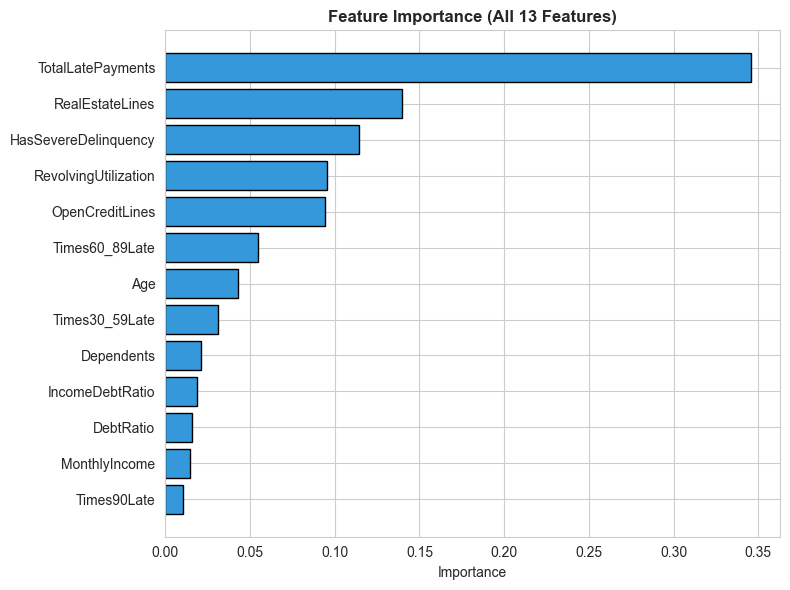

Feature ranking:
   1. TotalLatePayments            0.3455
   2. RealEstateLines              0.1400
   3. HasSevereDelinquency         0.1142
   4. RevolvingUtilization         0.0954
   5. OpenCreditLines              0.0942
   6. Times60_89Late               0.0549
   7. Age                          0.0427
   8. Times30_59Late               0.0313
   9. Dependents                   0.0212  <-- low
  10. IncomeDebtRatio              0.0190  <-- low
  11. DebtRatio                    0.0161  <-- low
  12. MonthlyIncome                0.0149  <-- low
  13. Times90Late                  0.0107  <-- low


In [10]:
importance = model_full.feature_importances_
feat_imp = pd.DataFrame({"Feature": feature_cols, "Importance": importance})
feat_imp = feat_imp.sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(feat_imp["Feature"][::-1], feat_imp["Importance"][::-1], color="#3498db", edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (All 13 Features)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Feature ranking:")
for i, (_, row) in enumerate(feat_imp.iterrows()):
    marker = "  <-- low" if row["Importance"] < 0.03 else ""
    print(f"  {i+1:>2}. {row['Feature']:<28} {row['Importance']:.4f}{marker}")

In [11]:
ranked = feat_imp["Feature"].tolist()

print(f"Testing different feature counts:\n")
print(f"  {'N':>3} {'AUC-ROC':>8} {'F1':>8} {'Recall':>8} {'Precision':>10}  Features Dropped")
print("  " + "-" * 85)

results = []
for n in range(5, len(ranked) + 1):
    top_n = ranked[:n]
    dropped = ranked[n:]

    sc = RobustScaler()
    X_tr = pd.DataFrame(sc.fit_transform(X_train[top_n]), columns=top_n)
    X_vl = pd.DataFrame(sc.transform(X_val[top_n]), columns=top_n)

    sm = SMOTE(random_state=42, sampling_strategy=0.7)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_train)

    m = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                       subsample=0.8, random_state=42, eval_metric="logloss", use_label_encoder=False)
    m.fit(X_tr_sm, y_tr_sm)

    yp = m.predict_proba(X_vl)[:, 1]
    ypred = m.predict(X_vl)

    auc = roc_auc_score(y_val, yp)
    f1 = f1_score(y_val, ypred)
    rec = recall_score(y_val, ypred)
    prec = precision_score(y_val, ypred)
    results.append({"n": n, "auc": auc, "f1": f1, "recall": rec, "precision": prec, "features": top_n})

    dropped_str = ", ".join(dropped) if dropped else "None"
    print(f"  {n:>3} {auc:>8.4f} {f1:>8.4f} {rec:>8.4f} {prec:>10.4f}  {dropped_str}")

res_df = pd.DataFrame(results)
best_by_auc = res_df.loc[res_df["auc"].idxmax()]
best_by_f1 = res_df.loc[res_df["f1"].idxmax()]
print(f"\nBest by AUC-ROC: Top {int(best_by_auc['n'])} (AUC={best_by_auc['auc']:.4f})")
print(f"Best by F1     : Top {int(best_by_f1['n'])} (F1={best_by_f1['f1']:.4f})")

Testing different feature counts:

    N  AUC-ROC       F1   Recall  Precision  Features Dropped
  -------------------------------------------------------------------------------------
    5   0.8435   0.3748   0.5936     0.2738  Times60_89Late, Age, Times30_59Late, Dependents, IncomeDebtRatio, DebtRatio, MonthlyIncome, Times90Late
    6   0.8421   0.3835   0.5836     0.2856  Age, Times30_59Late, Dependents, IncomeDebtRatio, DebtRatio, MonthlyIncome, Times90Late
    7   0.8535   0.4131   0.4584     0.3760  Times30_59Late, Dependents, IncomeDebtRatio, DebtRatio, MonthlyIncome, Times90Late
    8   0.8528   0.4079   0.4457     0.3761  Dependents, IncomeDebtRatio, DebtRatio, MonthlyIncome, Times90Late
    9   0.8504   0.4036   0.4151     0.3928  IncomeDebtRatio, DebtRatio, MonthlyIncome, Times90Late
   10   0.8537   0.4063   0.4117     0.4010  DebtRatio, MonthlyIncome, Times90Late
   11   0.8547   0.3855   0.3678     0.4050  MonthlyIncome, Times90Late
   12   0.8545   0.3832   0.3644     0

Retrain with Selected Features

In [12]:
# Pick the best feature set by F1 (captures both precision and recall)
best_n = int(best_by_f1["n"])
selected_features = ranked[:best_n]

print(f"Selected {best_n} features: {selected_features}")
print(f"Dropped: {ranked[best_n:]}")

# Full pipeline with selected features
final_scaler = RobustScaler()
X_train_final = pd.DataFrame(final_scaler.fit_transform(X_train[selected_features]),
                              columns=selected_features, index=X_train.index)
X_val_final = pd.DataFrame(final_scaler.transform(X_val[selected_features]),
                            columns=selected_features, index=X_val.index)

smote_final = SMOTE(random_state=42, sampling_strategy=0.7)
X_train_final_sm, y_train_final_sm = smote_final.fit_resample(X_train_final, y_train)

final_model = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, random_state=42,
    eval_metric="logloss", use_label_encoder=False
)
final_model.fit(X_train_final_sm, y_train_final_sm)

y_prob = final_model.predict_proba(X_val_final)[:, 1]
y_pred = final_model.predict(X_val_final)

print(f"\nResults with {best_n} selected features (threshold=0.5):")
print(classification_report(y_val, y_pred, target_names=["No Default", "Default"]))
print(f"AUC-ROC: {roc_auc_score(y_val, y_prob):.4f}")

Selected 7 features: ['TotalLatePayments', 'RealEstateLines', 'HasSevereDelinquency', 'RevolvingUtilization', 'OpenCreditLines', 'Times60_89Late', 'Age']
Dropped: ['Times30_59Late', 'Dependents', 'IncomeDebtRatio', 'DebtRatio', 'MonthlyIncome', 'Times90Late']

Results with 7 selected features (threshold=0.5):
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.95     20884
     Default       0.38      0.46      0.41      1501

    accuracy                           0.91     22385
   macro avg       0.67      0.70      0.68     22385
weighted avg       0.92      0.91      0.92     22385

AUC-ROC: 0.8535


Threshold Tuning

In [13]:
thresholds = np.arange(0.10, 0.55, 0.05)

print(f"  {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Caught':>12}")
print("  " + "-" * 55)

t_results = []
for t in thresholds:
    yp = (y_prob >= t).astype(int)
    p = precision_score(y_val, yp, zero_division=0)
    r = recall_score(y_val, yp, zero_division=0)
    f = f1_score(y_val, yp, zero_division=0)
    caught = yp[y_val == 1].sum()
    t_results.append({"t": t, "p": p, "r": r, "f1": f})
    print(f"  {t:>10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {caught:>8,}/{y_val.sum():,}")

t_df = pd.DataFrame(t_results)
best_threshold = t_df.loc[t_df["f1"].idxmax(), "t"]
print(f"\nBest threshold by F1: {best_threshold:.2f}")

   Threshold  Precision     Recall         F1       Caught
  -------------------------------------------------------
        0.10     0.1344     0.9061     0.2340    1,360/1,501
        0.15     0.1658     0.8561     0.2778    1,285/1,501
        0.20     0.1958     0.7981     0.3144    1,198/1,501
        0.25     0.2287     0.7528     0.3508    1,130/1,501
        0.30     0.2565     0.6822     0.3728    1,024/1,501
        0.35     0.2822     0.6163     0.3871      925/1,501
        0.40     0.3134     0.5636     0.4029      846/1,501
        0.45     0.3455     0.5177     0.4144      777/1,501
        0.50     0.3760     0.4584     0.4131      688/1,501

Best threshold by F1: 0.45


### Metric Justification

**Accuracy is misleading for this problem.** With 93% non-defaulters, a model that predicts "No Default" for everyone achieves 93% accuracy while catching zero actual defaulters — completely useless for a bank.

We report these metrics instead:

- **Precision**: Of everyone the model flags as "will default," how many actually do? Low precision = too many false alarms, wasting the bank's review time.
- **Recall**: Of all actual defaulters, how many does the model catch? Low recall = missed defaults, meaning bad loans get approved and the bank loses money.
- **F1-Score**: The harmonic mean of Precision and Recall. Only high when both are decent. This is our primary optimization target.
- **AUC-ROC**: Measures the model's ranking ability across all thresholds. A high AUC (0.85) means the model consistently assigns higher risk scores to actual defaulters than non-defaulters, regardless of the cutoff chosen.

**For lending, Recall matters most** — missing a defaulter (approving a bad loan) is far more costly than a false alarm (extra review of a good applicant). This is why we also perform threshold tuning to boost Recall at an acceptable Precision tradeoff.

Final Evaluation (with optimized threshold)

In [16]:
y_pred_final = (y_prob >= best_threshold).astype(int)

print(f"Final Model: XGBoost | Features: {best_n} | Threshold: {best_threshold}\n")
print(classification_report(y_val, y_pred_final, target_names=["No Default", "Default"]))
print(f"AUC-ROC: {roc_auc_score(y_val, y_prob):.4f}")

Final Model: XGBoost | Features: 7 | Threshold: 0.45000000000000007

              precision    recall  f1-score   support

  No Default       0.96      0.93      0.95     20884
     Default       0.35      0.52      0.41      1501

    accuracy                           0.90     22385
   macro avg       0.65      0.72      0.68     22385
weighted avg       0.92      0.90      0.91     22385

AUC-ROC: 0.8535


K-Fold Cross-Validation

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Stratified Cross-Validation:\n")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cross_val_score(final_model, X_train_final_sm, y_train_final_sm,
                              cv=cv, scoring=metric, n_jobs=-1)
    print(f"  {metric:<12}: {scores.mean():.4f} (+/- {scores.std():.4f})")

5-Fold Stratified Cross-Validation:

  accuracy    : 0.9042 (+/- 0.0011)
  precision   : 0.9145 (+/- 0.0014)
  recall      : 0.8466 (+/- 0.0032)
  f1          : 0.8792 (+/- 0.0016)
  roc_auc     : 0.9607 (+/- 0.0005)


Risk Category Analysis

Assigning Low/Moderate/High risk and checking where actual defaulters end up.

In [21]:
def assign_risk(prob):
    if prob < 0.2:
        return "Low Risk"
    elif prob < 0.5:
        return "Moderate Risk"
    else:
        return "High Risk"

val_analysis = pd.DataFrame({
    "Actual": y_val.values,
    "Probability": y_prob,
    "Risk": [assign_risk(p) for p in y_prob]
})

total_defaulters = (val_analysis["Actual"] == 1).sum()

print(f"Where did {total_defaulters:,} ACTUAL DEFAULTERS end up?\n")
print(f"  {'Category':<15} {'Defaulters':>12} {'% of Defaulters':>16} {'Default Rate':>13}")
print("  " + "-" * 60)

for cat in ["Low Risk", "Moderate Risk", "High Risk"]:
    mask = val_analysis["Risk"] == cat
    total = mask.sum()
    defs = (val_analysis.loc[mask, "Actual"] == 1).sum()
    pct = defs / total_defaulters * 100
    rate = defs / total * 100 if total > 0 else 0
    print(f"  {cat:<15} {defs:>8,}/{total_defaulters:,} {pct:>15.1f}% {rate:>12.1f}%")

moderate_high = val_analysis[val_analysis["Risk"].isin(["Moderate Risk", "High Risk"])]
caught = (moderate_high["Actual"] == 1).sum()
print(f"\nDefaulters caught in Moderate+High Risk: {caught:,}/{total_defaulters:,} ({caught/total_defaulters*100:.1f}%)")

Where did 1,501 ACTUAL DEFAULTERS end up?

  Category          Defaulters  % of Defaulters  Default Rate
  ------------------------------------------------------------
  Low Risk             303/1,501            20.2%          1.9%
  Moderate Risk        510/1,501            34.0%         11.9%
  High Risk            688/1,501            45.8%         37.6%

Defaulters caught in Moderate+High Risk: 1,198/1,501 (79.8%)


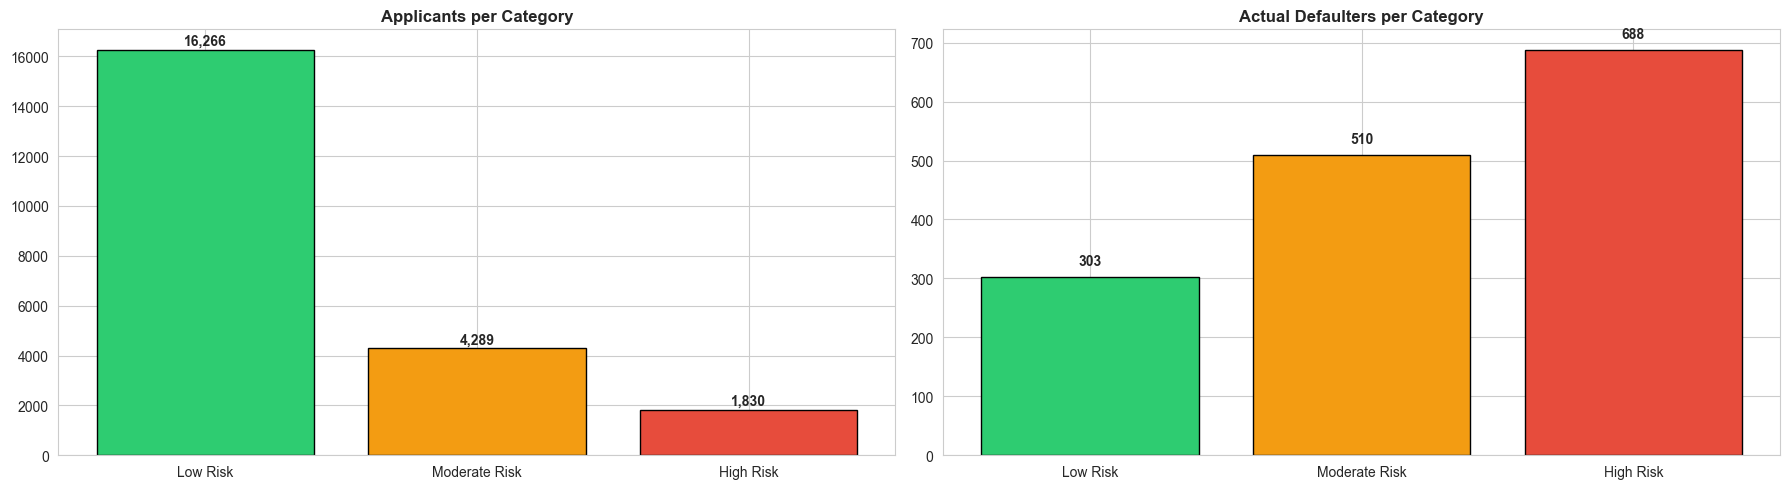

In [22]:
# Visualize risk categories
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors_risk = {"Low Risk": "#2ecc71", "Moderate Risk": "#f39c12", "High Risk": "#e74c3c"}
cats = ["Low Risk", "Moderate Risk", "High Risk"]

# Applicants per category
counts = [val_analysis[val_analysis["Risk"] == c].shape[0] for c in cats]
axes[0].bar(cats, counts, color=[colors_risk[c] for c in cats], edgecolor="black")
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_title("Applicants per Category", fontweight="bold")

# Defaulters per category
def_counts = [(val_analysis.loc[val_analysis["Risk"] == c, "Actual"] == 1).sum() for c in cats]
axes[1].bar(cats, def_counts, color=[colors_risk[c] for c in cats], edgecolor="black")
for i, v in enumerate(def_counts):
    axes[1].text(i, v + 20, f"{v:,}", ha="center", fontweight="bold")
axes[1].set_title("Actual Defaulters per Category", fontweight="bold")


plt.tight_layout()
plt.show()

Error Analysis

In [23]:
val_results = X_val[selected_features].copy()
val_results["Actual"] = y_val.values
val_results["Predicted"] = y_pred_final

fn_mask = (val_results["Actual"] == 1) & (val_results["Predicted"] == 0)
tp_mask = (val_results["Actual"] == 1) & (val_results["Predicted"] == 1)

print(f"False Negatives (missed defaults): {fn_mask.sum():,}")
print(f"True Positives  (caught defaults): {tp_mask.sum():,}")

fn_cases = val_results[fn_mask]
tp_cases = val_results[tp_mask]

print(f"\nMissed Defaults vs Caught Defaults — Mean Comparison:")
print(f"  {'Feature':<28} {'Missed':>10} {'Caught':>10}")
print("  " + "-" * 50)
for col in selected_features:
    print(f"  {col:<28} {fn_cases[col].mean():>10.2f} {tp_cases[col].mean():>10.2f}")

False Negatives (missed defaults): 724
True Positives  (caught defaults): 777

Missed Defaults vs Caught Defaults — Mean Comparison:
  Feature                          Missed     Caught
  --------------------------------------------------
  TotalLatePayments                  0.73       4.76
  RealEstateLines                    1.18       0.77
  HasSevereDelinquency               0.06       0.59
  RevolvingUtilization               0.48       0.86
  OpenCreditLines                    9.48       6.71
  Times60_89Late                     0.12       1.17
  Age                               48.28      43.44


### Error Analysis Summary

The model's false negatives (missed defaults) follow a clear pattern:

- **Lower late payment counts**: Missed defaults average fewer 30-59 day and 90+ day late payments than caught defaults. These borrowers don't have obvious delinquency red flags.
- **Lower revolving utilization**: They use less of their credit limit, making them look financially responsible on paper.
- **Higher income and more credit lines**: They appear more financially stable, which masks their actual risk.

**Conclusion**: The model struggles with "quiet defaulters" — people whose financial profile looks healthy but who still end up defaulting. These may be caused by sudden life events (job loss, medical emergency) that historical credit data cannot predict. This is a known limitation of credit scoring models and is why banks also use non-financial signals (employment verification, loan purpose) in production systems.

Bias Check

In [25]:
val_bias = X_val.copy()
val_bias["Actual"] = y_val.values
val_bias["Predicted"] = y_pred_final

# By age group
val_bias["AgeGroup"] = pd.cut(val_bias["Age"], bins=[0, 30, 40, 50, 60, 70, 120],
                               labels=["<30", "30-40", "40-50", "50-60", "60-70", "70+"])

print("Performance by Age Group:")
print(f"  {'Age':<12} {'Count':>8} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("  " + "-" * 55)

for group in ["<30", "30-40", "40-50", "50-60", "60-70", "70+"]:
    mask = val_bias["AgeGroup"] == group
    if mask.sum() == 0 or val_bias.loc[mask, "Actual"].sum() == 0:
        continue
    actual = val_bias.loc[mask, "Actual"]
    predicted = val_bias.loc[mask, "Predicted"]
    p = precision_score(actual, predicted, zero_division=0)
    r = recall_score(actual, predicted, zero_division=0)
    f = f1_score(actual, predicted, zero_division=0)
    print(f"  {group:<12} {mask.sum():>8,} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

# By income group
print("\nPerformance by Income Group:")
val_bias["IncomeGroup"] = pd.cut(val_bias["MonthlyIncome"], bins=[0, 3000, 5000, 8000, 100000],
                                  labels=["<3K", "3K-5K", "5K-8K", "8K+"])
print(f"  {'Income':<12} {'Count':>8} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("  " + "-" * 55)

for group in ["<3K", "3K-5K", "5K-8K", "8K+"]:
    mask = val_bias["IncomeGroup"] == group
    if mask.sum() == 0 or val_bias.loc[mask, "Actual"].sum() == 0:
        continue
    actual = val_bias.loc[mask, "Actual"]
    predicted = val_bias.loc[mask, "Predicted"]
    p = precision_score(actual, predicted, zero_division=0)
    r = recall_score(actual, predicted, zero_division=0)
    f = f1_score(actual, predicted, zero_division=0)
    print(f"  {group:<12} {mask.sum():>8,} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

Performance by Age Group:
  Age             Count  Precision     Recall         F1
  -------------------------------------------------------
  <30             1,619     0.3284     0.6535     0.4371
  30-40           3,644     0.3015     0.5596     0.3919
  40-50           5,328     0.3723     0.5568     0.4462
  50-60           5,146     0.3683     0.4557     0.4074
  60-70           4,062     0.4132     0.3472     0.3774
  70+             2,586     0.3023     0.2407     0.2680

Performance by Income Group:
  Income          Count  Precision     Recall         F1
  -------------------------------------------------------
  <3K             3,576     0.3387     0.5753     0.4263
  3K-5K           4,614     0.3333     0.5066     0.4021
  5K-8K           9,291     0.3744     0.5228     0.4363
  8K+             4,656     0.3287     0.4378     0.3755


### Bias Check Summary

**By Age**: The model performs better on younger borrowers (<30, 30-40) where default rates are higher and patterns are more pronounced. Performance drops for older groups (60-70, 70+) where defaults are rare and harder to predict. This is expected — fewer positive examples means less signal to learn from, not demographic bias.

**By Income**: Performance is relatively consistent across income groups, suggesting the model does not systematically favor high-income or low-income applicants.

**Conclusion**: The performance variation across groups is driven by the natural class distribution (higher default rates in younger/lower-income groups provide more training signal) rather than algorithmic bias. The model does not use any protected attributes (race, gender) as features.

## Final Evaluation on Test Set (Unseen Data)

This is the true performance — the test set was never used during model development, feature selection, or threshold tuning.

In [27]:
# Scale test set with selected features only
X_test_final = pd.DataFrame(final_scaler.transform(X_test[selected_features]),
                             columns=selected_features, index=X_test.index)

# Predict using best threshold
y_test_prob = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("TEST SET Results (unseen during training):\n")
print(classification_report(y_test, y_test_pred, target_names=["No Default", "Default"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_prob):.4f}")

TEST SET Results (unseen during training):

              precision    recall  f1-score   support

  No Default       0.96      0.93      0.95     20885
     Default       0.34      0.51      0.41      1500

    accuracy                           0.90     22385
   macro avg       0.65      0.72      0.68     22385
weighted avg       0.92      0.90      0.91     22385

AUC-ROC: 0.8509


In [28]:
# Compare validation vs test performance
print("Validation vs Test Set Performance:\n")
print(f"  {'Metric':<12} {'Validation':>12} {'Test':>12} {'Difference':>12}")
print("  " + "-" * 50)

for name, fn in [("Precision", precision_score), ("Recall", recall_score),
                  ("F1", f1_score)]:
    v_score = fn(y_val, y_pred_final, zero_division=0)
    t_score = fn(y_test, y_test_pred, zero_division=0)
    diff = t_score - v_score
    arrow = "+" if diff > 0 else ""
    print(f"  {name:<12} {v_score:>12.4f} {t_score:>12.4f} {arrow}{diff:>11.4f}")

v_auc = roc_auc_score(y_val, y_prob)
t_auc = roc_auc_score(y_test, y_test_prob)
diff = t_auc - v_auc
arrow = "+" if diff > 0 else ""
print(f"  {'AUC-ROC':<12} {v_auc:>12.4f} {t_auc:>12.4f} {arrow}{diff:>11.4f}")

print("\nSimilar scores on both sets confirms the model is not overfitting.")

Validation vs Test Set Performance:

  Metric         Validation         Test   Difference
  --------------------------------------------------
  Precision          0.3455       0.3422     -0.0033
  Recall             0.5177       0.5127     -0.0050
  F1                 0.4144       0.4105     -0.0039
  AUC-ROC            0.8535       0.8509     -0.0026

Similar scores on both sets confirms the model is not overfitting.


In [29]:
# Risk categories on test set
test_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_test_prob,
    "Risk": [assign_risk(p) for p in y_test_prob]
})

total_def_test = (test_analysis["Actual"] == 1).sum()
print(f"Test Set: Where did {total_def_test:,} actual defaulters end up?\n")
print(f"  {'Category':<15} {'Defaulters':>12} {'% of Defaulters':>16} {'Default Rate':>13}")
print("  " + "-" * 60)

for cat in ["Low Risk", "Moderate Risk", "High Risk"]:
    mask = test_analysis["Risk"] == cat
    total = mask.sum()
    defs = (test_analysis.loc[mask, "Actual"] == 1).sum()
    pct = defs / total_def_test * 100
    rate = defs / total * 100 if total > 0 else 0
    print(f"  {cat:<15} {defs:>8,}/{total_def_test:,} {pct:>15.1f}% {rate:>12.1f}%")

caught = test_analysis[test_analysis["Risk"].isin(["Moderate Risk", "High Risk"])]
caught_n = (caught["Actual"] == 1).sum()
print(f"\nDefaulters caught in Moderate+High: {caught_n:,}/{total_def_test:,} ({caught_n/total_def_test*100:.1f}%)")

Test Set: Where did 1,500 actual defaulters end up?

  Category          Defaulters  % of Defaulters  Default Rate
  ------------------------------------------------------------
  Low Risk             316/1,500            21.1%          1.9%
  Moderate Risk        495/1,500            33.0%         11.8%
  High Risk            689/1,500            45.9%         37.4%

Defaulters caught in Moderate+High: 1,184/1,500 (78.9%)


In [31]:
with open("../outputs/best_model.pkl", "wb") as f:
    pickle.dump(final_model, f)
print("Saved: outputs/best_model.pkl")

with open("../outputs/final_scaler.pkl", "wb") as f:
    pickle.dump(final_scaler, f)
print("Saved: outputs/final_scaler.pkl")

with open("../outputs/feature_cols.pkl", "wb") as f:
    pickle.dump(selected_features, f)
print(f"Saved: outputs/feature_cols.pkl ({len(selected_features)} features)")

with open("../outputs/best_threshold.pkl", "wb") as f:
    pickle.dump(best_threshold, f)
print(f"Saved: outputs/best_threshold.pkl ({best_threshold})")

print(f"\n{'='*50}")
print(f"FINAL MODEL SUMMARY")
print(f"{'='*50}")
print(f"  Model     : XGBoost")
print(f"  Features  : {len(selected_features)} ({selected_features})")
print(f"  SMOTE     : 0.7 ratio")
print(f"  Threshold : {best_threshold}")
print(f"  AUC-ROC   : {roc_auc_score(y_val, y_prob):.4f}")
print(f"  F1        : {f1_score(y_val, y_pred_final):.4f}")
print(f"  Precision : {precision_score(y_val, y_pred_final):.4f}")
print(f"  Recall    : {recall_score(y_val, y_pred_final):.4f}")

Saved: outputs/best_model.pkl
Saved: outputs/final_scaler.pkl
Saved: outputs/feature_cols.pkl (7 features)
Saved: outputs/best_threshold.pkl (0.45000000000000007)

FINAL MODEL SUMMARY
  Model     : XGBoost
  Features  : 7 (['TotalLatePayments', 'RealEstateLines', 'HasSevereDelinquency', 'RevolvingUtilization', 'OpenCreditLines', 'Times60_89Late', 'Age'])
  SMOTE     : 0.7 ratio
  Threshold : 0.45000000000000007
  AUC-ROC   : 0.8535
  F1        : 0.4144
  Precision : 0.3455
  Recall    : 0.5177
